# 22 — Gateway Decision Analysis: LSTM Surrogate vs Ground Truth (U-ED-LSTM Sepsis)

For each **decision point** (gateway) in the process, trains two decision trees
on identical prefixes:

1. **LSTM Surrogate** — target = model's predicted next activity
2. **Ground Truth** — target = actual next activity from the event log

Compares rules, feature importances, and agreement to reveal whether the LSTM
has learned the same decision logic that exists in the data.

In [31]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [32]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from src.interpretability.surrogate.c45_tree import C45Classifier
from src.interpretability.config.sepsis_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant

# --- Load dataset ---
dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder
decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = CONFIG.concept_name
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor
predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# Activity-tensor index (only one used downstream by extract_features and the
# DFG construction loop).
ACT_IDX = decoder.cat_features.index(ACTIVITY_FEATURE)

print(f'Activity feature: {ACTIVITY_FEATURE} (idx={ACT_IDX})')
print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

Dataset: 3251 sequences, 26 cat, 8 num, seq_len=51
Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('InfectionSuspected', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('DiagnosticBlood', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('DisfuncOrg', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritTachypnea', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Hypotensie', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritHeartRate', 5, {'EO

## Build DFG and identify qualifying gateways

A gateway is an activity with more than one observed successor. We filter to
gateways with at least `MIN_CASES` prefixes and at least two branches with
`MIN_BRANCH` cases each, so the decision trees have enough data.

In [33]:
MIN_CASES = 4       # minimum prefixes at this gateway
MIN_BRANCH = 4      # minimum cases per branch (need at least 2 branches above this)
MIN_SAMPLES_LEAF = 5

ACTIVITY_WINDOW = 40                # number of recent events to include as positional features
CASE_LEVEL_THRESHOLD = 0.95     # feature is case-level if it's constant within a case in >=95% of cases

# Override the data-driven classification: features whose true value is recorded
# only at the registration event and mean-imputed elsewhere (e.g. 'Age' in Sepsis)
# look event-level after imputation, but should be treated as case-level. The
# value at the *first* event of the prefix is used (see extract_features).
# Set to empty sets to disable the override and fall back to the heuristic.
FORCE_CASE_LEVEL_NUMERIC = {'Age'}
FORCE_CASE_LEVEL_CATEGORICAL = {
    'InfectionSuspected',
    'DiagnosticBlood', 'DiagnosticArtAstrup', 'DiagnosticIC',
    'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther',
    'DiagnosticXthorax', 'DiagnosticUrinaryCulture', 'DiagnosticLacticAcid',
    'DisfuncOrg', 'Hypotensie', 'Oligurie', 'Infusion',
    'SIRSCritTachypnea', 'SIRSCritHeartRate', 'SIRSCritTemperature',
    'SIRSCritLeucos', 'SIRSCriteria2OrMore',
}

# --- Collect unique cases (longest trace per case_id) ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'{len(cases)} unique cases')

# --- Data-driven classification: event-level vs case-level ---
# A feature is case-level if at least CASE_LEVEL_THRESHOLD of cases have a single
# constant value across all real (non-EOS) events of the case.
_n_cat_const = [0] * n_cat
_n_num_const = [0] * n_num
_total_checked = 0
for _cid, (_idx, _L) in cases.items():
    _cat_t, _num_t, _ = dataset[_idx]
    _s = seq_len - _L
    _useful = _L
    for _j in range(_L - 1, -1, -1):
        if _cat_t[ACT_IDX][_s + _j].item() == eos_idx:
            _useful = _j
        else:
            break
    if _useful == 0:
        continue
    _total_checked += 1
    for _ci in range(n_cat):
        _vals = _cat_t[_ci][_s:_s + _useful].tolist()
        if len(set(_vals)) == 1:
            _n_cat_const[_ci] += 1
    for _ni in range(n_num):
        _vals = _num_t[_ni][_s:_s + _useful].tolist()
        if max(_vals) - min(_vals) < 1e-6:
            _n_num_const[_ni] += 1

EVENT_CAT_INDICES = [i for i in range(n_cat)
                     if _n_cat_const[i] / _total_checked < CASE_LEVEL_THRESHOLD
                     and decoder.cat_features[i] not in FORCE_CASE_LEVEL_CATEGORICAL]
EVENT_NUM_INDICES = [i for i in range(n_num)
                     if _n_num_const[i] / _total_checked < CASE_LEVEL_THRESHOLD
                     and decoder.num_features[i] not in FORCE_CASE_LEVEL_NUMERIC]

print(f'\nFeature classification (threshold: {CASE_LEVEL_THRESHOLD:.0%} constant -> case-level, '
      f'based on {_total_checked} cases):')
for _ci in range(n_cat):
    _pct = _n_cat_const[_ci] / _total_checked
    _tag = 'event-level' if _ci in EVENT_CAT_INDICES else 'CASE-LEVEL'
    if decoder.cat_features[_ci] in FORCE_CASE_LEVEL_CATEGORICAL:
        _tag += ' (forced)'
    print(f'  cat[{_ci}] {decoder.cat_features[_ci]:35s} {_pct:5.1%} constant  -> {_tag}')
for _ni in range(n_num):
    _pct = _n_num_const[_ni] / _total_checked
    _tag = 'event-level' if _ni in EVENT_NUM_INDICES else 'CASE-LEVEL'
    if decoder.num_features[_ni] in FORCE_CASE_LEVEL_NUMERIC:
        _tag += ' (forced)'
    print(f'  num[{_ni}] {decoder.num_features[_ni]:35s} {_pct:5.1%} constant  -> {_tag}')

# --- Build DFG ---
dfg = {}
successors_map = {}

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    # Append synthetic 'EOS' so the case-end transition shows up in the DFG
    # (and gateways with EOS as a successor become qualifying decision points).
    act_names = [activity_names[acts[j].item()] for j in range(useful_len)] + ['EOS']
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'\nDecision points ({len(decision_points)}):')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c}, {c/total*100:.0f}%)' for s, c in
                         sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total} cases): {branches}')

209 unique cases

Feature classification (threshold: 95% constant -> case-level, based on 209 cases):
  cat[0] concept:name                         0.0% constant  -> event-level
  cat[1] InfectionSuspected                   0.0% constant  -> CASE-LEVEL (forced)
  cat[2] org:group                            0.0% constant  -> event-level
  cat[3] DiagnosticBlood                      0.0% constant  -> CASE-LEVEL (forced)
  cat[4] DisfuncOrg                           0.0% constant  -> CASE-LEVEL (forced)
  cat[5] SIRSCritTachypnea                    0.0% constant  -> CASE-LEVEL (forced)
  cat[6] Hypotensie                           0.0% constant  -> CASE-LEVEL (forced)
  cat[7] SIRSCritHeartRate                    0.0% constant  -> CASE-LEVEL (forced)
  cat[8] Infusion                             0.0% constant  -> CASE-LEVEL (forced)
  cat[9] DiagnosticArtAstrup                  0.0% constant  -> CASE-LEVEL (forced)
  cat[10] DiagnosticIC                         0.0% constant  -> CASE-LEVE

## Collect per-gateway prefixes

For each qualifying gateway, find every prefix that ends at that activity (where
a real next activity exists). Extract both the actual next activity and the
LSTM's prediction, plus engineered features for the surrogate trees.

In [34]:
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract features for a single prefix.

    Kept minimal: prefix_length, case-level features (cat + num) at the gateway
    position, and positional encoding over the last ACTIVITY_WINDOW events for
    every event-level categorical AND numerical feature.
    """
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    feats = {'prefix_length': prefix_len}

    # Case-level categorical features (event-level ones are covered by positional features below).
    # For features forced to case-level (FORCE_CASE_LEVEL_*), read from the first event of the
    # prefix -- that's where the true value sits before mean/category imputation kicks in.
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci in EVENT_CAT_INDICES:
            continue
        pos = start if feat_name in FORCE_CASE_LEVEL_CATEGORICAL else end - 1
        val = cat_tuple[ci][pos].item()
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, val))

    # Case-level numerical features (event-level ones are covered by positional features below).
    for ni, feat_name in enumerate(decoder.num_features):
        if ni in EVENT_NUM_INDICES:
            continue
        pos = start if feat_name in FORCE_CASE_LEVEL_NUMERIC else end - 1
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(
            feat_name, num_tuple[ni][pos].item())

    # Positional features for every event-level categorical feature (last ACTIVITY_WINDOW events)
    for ci in EVENT_CAT_INDICES:
        feat_name = decoder.cat_features[ci]
        tensor = cat_tuple[ci][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_categorical_value(ci, tensor[pos].item())
            else:
                feats[key] = '<pad>'

    # Positional features for every event-level numerical feature (last ACTIVITY_WINDOW events)
    for ni in EVENT_NUM_INDICES:
        feat_name = decoder.num_features[ni]
        tensor = num_tuple[ni][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_numerical_value(feat_name, tensor[pos].item())
            else:
                feats[key] = float('nan')

    return feats


# --- Collect gateway data ---
gateway_data = {}  # gateway_name -> {X, y_lstm, y_actual, cat_list, num_list}

for gateway_act, succs in decision_points.items():
    # Check if gateway qualifies
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows = []
    actual_labels = []
    cat_list = []
    num_list = []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        # Strip trailing EOS
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        # Iterate up to AND including the last real activity. When k == useful_len - 1
        # the next event is EOS (case end) -- include that as a training sample so
        # gateways like 'last_real_act -> EOS' get learned by the surrogate trees.
        for k in range(useful_len):
            act_idx_val = acts[k].item()
            if activity_names[act_idx_val] != gateway_act:
                continue

            if k < useful_len - 1:
                next_act_name = activity_names[acts[k + 1].item()]
            else:
                next_act_name = 'EOS'
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            # Build padded prefix tensors
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    # Batch-predict LSTM labels
    N = len(X)
    cat_batch = [
        torch.stack([cat_list[i][ci] for i in range(N)])
        for ci in range(n_cat)
    ]
    num_stacked = torch.stack([
        torch.stack(num_list[i], dim=-1) for i in range(N)
    ])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
        # Prefix tensors so notebook 23 can run IG on the exact rows the trees
        # were trained on without re-collecting / re-stratifying.
        'cat_list': cat_list, 'num_list': num_list,
    }

    # Report
    n_branches_actual = len(set(y_actual))
    n_branches_lstm = len(set(y_lstm))
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'\n{gateway_act}: {N} prefixes, '
          f'{n_branches_actual} actual branches, {n_branches_lstm} LSTM branches, '
          f'LSTM accuracy={lstm_acc:.3f}')
    print(f'  Actual distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_actual, return_counts=True))))
    print(f'  LSTM   distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_lstm, return_counts=True))))

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')


ER Registration: 209 prefixes, 6 actual branches, 1 LSTM branches, LSTM accuracy=0.010
  Actual distribution: CRP (2), ER Sepsis Triage (1), ER Triage (191), IV Liquid (7), LacticAcid (4), Leucocytes (4)
  LSTM   distribution: CRP (209)

ER Triage: 209 prefixes, 5 actual branches, 1 LSTM branches, LSTM accuracy=0.043
  Actual distribution: CRP (9), ER Registration (1), ER Sepsis Triage (182), LacticAcid (9), Leucocytes (8)
  LSTM   distribution: CRP (209)

ER Sepsis Triage: 209 prefixes, 7 actual branches, 1 LSTM branches, LSTM accuracy=0.148
  Actual distribution: Admission NC (6), CRP (31), EOS (11), IV Antibiotics (18), IV Liquid (53), LacticAcid (28), Leucocytes (62)
  LSTM   distribution: CRP (209)

IV Liquid: 142 prefixes, 10 actual branches, 2 LSTM branches, LSTM accuracy=0.077
  Actual distribution: Admission IC (2), Admission NC (11), CRP (12), EOS (2), ER Registration (1), ER Sepsis Triage (2), ER Triage (9), IV Antibiotics (86), LacticAcid (7), Leucocytes (10)
  LSTM   dist

## Train surrogate and ground truth trees per gateway

For each gateway, the same stratified 60/20/20 train/validation/test
split is used for both trees so they are fit on identical training data,
selected on identical validation data, and evaluated on identical
held-out test data. Depth is swept on the validation set and the
shallowest tree within 2% of the best validation score is selected.
Final fidelity, accuracy, and agreement metrics are reported on the
held-out test set.

In [35]:
def select_best_depth(X_train, y_train, X_val, y_val, cat_features,
                      depths=(3, 4, 5, 6, 7, 8)):
    """Sweep depths on validation set; prefer shallowest within 2% of best."""
    results = []
    for depth in depths:
        clf = C45Classifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train, categorical_features=cat_features)
        train_sc = clf.score(X_train, y_train)
        val_sc = clf.score(X_val, y_val)
        results.append({'depth': depth, 'train': train_sc, 'val': val_sc, 'clf': clf})

    best_idx = 0
    best_val = results[0]['val']
    for i in range(1, len(results)):
        if results[i]['val'] > best_val + 0.02:
            best_idx = i
            best_val = results[i]['val']
    return results[best_idx]['clf'], results


# --- Train trees for each gateway ---
gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    # Identify categorical columns (object dtype)
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    # --- Three-way split: 60% train / 20% validation / 20% test ---
    # First split: 80% trainval / 20% test (held out for final metrics)
    try:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2, random_state=42)

    # Second split: 75% of trainval = 60% total for training, 25% of trainval = 20% total for validation
    try:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25,
                             random_state=42, stratify=y_actual_tv)
    except ValueError:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25, random_state=42)

    feature_names = list(X.columns)

    # Train C4.5 trees on train set, select depth on validation set
    clf_lstm, lstm_sweep = select_best_depth(
        X_train, y_lstm_train, X_val, y_lstm_val, cat_cols)
    clf_gt, gt_sweep = select_best_depth(
        X_train, y_actual_train, X_val, y_actual_val, cat_cols)

    # --- Final metrics on held-out TEST set ---
    surrogate_fidelity = clf_lstm.score(X_test, y_lstm_test)
    gt_accuracy = clf_gt.score(X_test, y_actual_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()
    agreement = (clf_lstm.predict(X_test) == clf_gt.predict(X_test)).mean()

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'cat_cols': cat_cols,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_lstm_train': y_lstm_train, 'y_lstm_val': y_lstm_val, 'y_lstm_test': y_lstm_test,
        'y_actual_train': y_actual_train, 'y_actual_val': y_actual_val, 'y_actual_test': y_actual_test,
        'surrogate_fidelity': surrogate_fidelity,
        'gt_accuracy': gt_accuracy,
        'lstm_accuracy': lstm_accuracy,
        'agreement': agreement,
        'n_cases': len(X),
        'lstm_sweep': lstm_sweep, 'gt_sweep': gt_sweep,
    }

    print(f'\n{"=" * 70}')
    print(f'Gateway: {gateway_act} ({len(X)} prefixes: '
          f'{len(X_train)} train / {len(X_val)} val / {len(X_test)} test)')
    print(f'  LSTM accuracy at gateway:     {lstm_accuracy:.3f}')
    print(f'  Surrogate fidelity (vs LSTM): {surrogate_fidelity:.3f}  '
          f'(depth={clf_lstm.get_depth()}, leaves={clf_lstm.get_n_leaves()})')
    print(f'  Ground truth tree accuracy:   {gt_accuracy:.3f}  '
          f'(depth={clf_gt.get_depth()}, leaves={clf_gt.get_n_leaves()})')
    print(f'  Agreement (surrogate vs GT):  {agreement:.3f}')


Gateway: ER Registration (209 prefixes: 125 train / 42 val / 42 test)
  LSTM accuracy at gateway:     0.000
  Surrogate fidelity (vs LSTM): 1.000  (depth=0, leaves=1)
  Ground truth tree accuracy:   0.881  (depth=0, leaves=1)
  Agreement (surrogate vs GT):  0.000

Gateway: ER Triage (209 prefixes: 125 train / 42 val / 42 test)
  LSTM accuracy at gateway:     0.024
  Surrogate fidelity (vs LSTM): 1.000  (depth=0, leaves=1)
  Ground truth tree accuracy:   0.881  (depth=0, leaves=1)
  Agreement (surrogate vs GT):  0.000

Gateway: ER Sepsis Triage (209 prefixes: 125 train / 42 val / 42 test)
  LSTM accuracy at gateway:     0.143
  Surrogate fidelity (vs LSTM): 1.000  (depth=0, leaves=1)
  Ground truth tree accuracy:   0.333  (depth=2, leaves=3)
  Agreement (surrogate vs GT):  0.000

Gateway: IV Liquid (142 prefixes: 84 train / 29 val / 29 test)
  LSTM accuracy at gateway:     0.034
  Surrogate fidelity (vs LSTM): 1.000  (depth=0, leaves=1)
  Ground truth tree accuracy:   0.759  (depth=3, 

In [36]:
# === Empirical check: do the forced case-level features actually inform the GT decision? ===
# For each gateway: print the GT tree's top feature importances and, for every
# forced case-level feature, a compact decision table (feature value -> top
# next-activity branches). Use this to keep / remove entries from
# FORCE_CASE_LEVEL_* based on real discriminative power, not just schema.
import pandas as pd

_force_feats = FORCE_CASE_LEVEL_NUMERIC | FORCE_CASE_LEVEL_CATEGORICAL

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_actual = gd['y_actual']

    forced_cols = [f'last_{f}' for f in _force_feats if f'last_{f}' in X.columns]
    if not forced_cols:
        continue

    print(f'\n{"=" * 72}')
    print(f'GATEWAY: {gateway_act}  (n={len(X)})')
    _vals, _cnts = np.unique(y_actual, return_counts=True)
    print(f'  next-activity distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      sorted(zip(_vals, _cnts), key=lambda x: -x[1])))

    res = gateway_results.get(gateway_act)
    if res is not None and res['clf_gt'].feature_importances_ is not None:
        imp = res['clf_gt'].feature_importances_
        feat_imp = sorted(zip(res['feature_names'], imp), key=lambda x: -x[1])
        top = [(f, i) for f, i in feat_imp if i > 0][:5]
        if top:
            print(f'  GT tree top features ({len(top)}):')
            for f, i in top:
                marker = '  <- forced' if f.startswith('last_') and f[5:] in _force_feats else ''
                print(f'    {f:40s} {i:.3f}{marker}')
        else:
            print(f'  GT tree: no splits (root-only)')

    print(f'  Decision tables for forced case-level features:')
    for col in forced_cols:
        col_vals = X[col].astype(str)
        n_unique = col_vals.nunique()
        if n_unique <= 1:
            print(f'    {col:40s} constant ({col_vals.iloc[0]!r}) -> no signal')
            continue
        ct = pd.crosstab(col_vals, y_actual)
        print(f'    {col} ({n_unique} unique values):')
        for val, row in ct.iterrows():
            total = int(row.sum())
            if total == 0:
                continue
            top_branches = row.sort_values(ascending=False).head(3)
            s = ', '.join(f'{a}={int(c)}' for a, c in top_branches.items() if c > 0)
            print(f'      {str(val)[:25]:25s} n={total:4d}  top: {s}')



GATEWAY: ER Registration  (n=209)
  next-activity distribution: ER Triage (191), IV Liquid (7), LacticAcid (4), Leucocytes (4), CRP (2), ER Sepsis Triage (1)
  GT tree: no splits (root-only)
  Decision tables for forced case-level features:
    last_DiagnosticOther (3 unique values):
      <none>                    n=   5  top: ER Triage=4, Leucocytes=1
      False                     n= 202  top: ER Triage=185, IV Liquid=7, LacticAcid=4
      True                      n=   2  top: ER Triage=2
    last_InfectionSuspected (3 unique values):
      <none>                    n=   5  top: ER Triage=4, Leucocytes=1
      False                     n=  44  top: ER Triage=44
      True                      n= 160  top: ER Triage=143, IV Liquid=7, LacticAcid=4
    last_Hypotensie (3 unique values):
      <none>                    n=   5  top: ER Triage=4, Leucocytes=1
      False                     n= 199  top: ER Triage=182, IV Liquid=7, LacticAcid=4
      True                      n=   5  to

## Summary table

In [37]:
summary_rows = []
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_
    top_lstm = fn[np.argmax(imp_lstm)]
    top_gt = fn[np.argmax(imp_gt)]

    summary_rows.append({
        'Gateway': gateway_act,
        '#Cases': gr['n_cases'],
        '#Branches (actual)': len(set(gr['y_actual_train']) | set(gr['y_actual_test'])),
        'LSTM Accuracy': f'{gr["lstm_accuracy"]:.3f}',
        'Surrogate Fidelity': f'{gr["surrogate_fidelity"]:.3f}',
        'GT Tree Accuracy': f'{gr["gt_accuracy"]:.3f}',
        'Agreement': f'{gr["agreement"]:.3f}',
        'Top LSTM Feature': top_lstm,
        'Top GT Feature': top_gt,
        'Same Top Feature': top_lstm == top_gt,
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Gateway,#Cases,#Branches (actual),LSTM Accuracy,Surrogate Fidelity,GT Tree Accuracy,Agreement,Top LSTM Feature,Top GT Feature,Same Top Feature
0,ER Registration,209,6,0.000,1.000,0.881,0.000,prefix_length,prefix_length,True
1,ER Triage,209,5,0.024,1.000,0.881,0.000,prefix_length,prefix_length,True
2,ER Sepsis Triage,209,7,0.143,1.000,0.333,0.000,prefix_length,day_in_week_pos_-6,False
3,IV Liquid,142,9,0.034,1.000,0.759,0.000,prefix_length,case_elapsed_time_pos_-7,False
4,Leucocytes,623,13,0.496,1.000,0.512,0.984,prefix_length,case_elapsed_time_pos_-10,False
5,CRP,571,13,0.130,0.983,0.400,0.113,case_elapsed_time_pos_-20,seconds_in_day_pos_-9,False
6,LacticAcid,263,10,0.208,1.000,0.396,0.019,prefix_length,case_elapsed_time_pos_-10,False
7,IV Antibiotics,161,9,0.061,1.000,0.606,0.000,prefix_length,prefix_length,True
8,Admission NC,211,11,0.209,0.512,0.279,0.023,seconds_in_day_pos_-16,case_elapsed_time_pos_-10,False
9,Release A,132,2,0.370,0.963,0.630,0.000,prefix_length,prefix_length,True


## Feature importance comparison

Side-by-side bar charts: which features does the LSTM surrogate rely on vs
which features explain the actual process decisions?

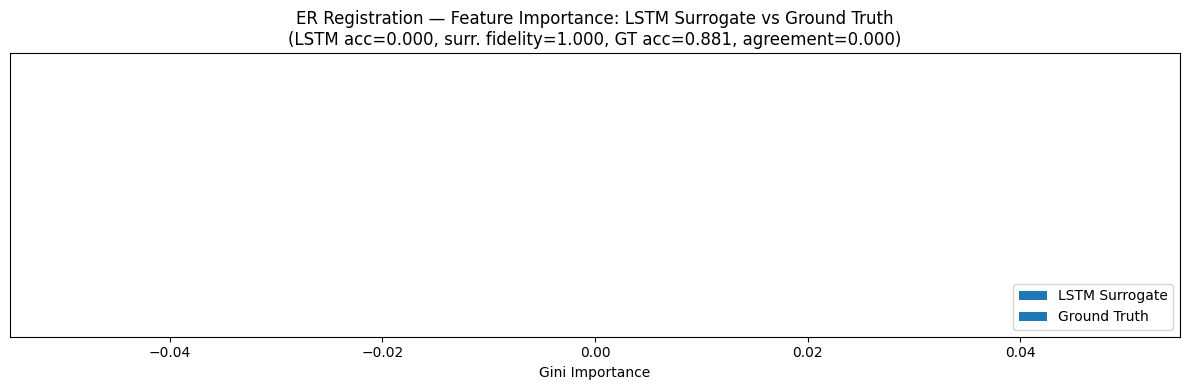

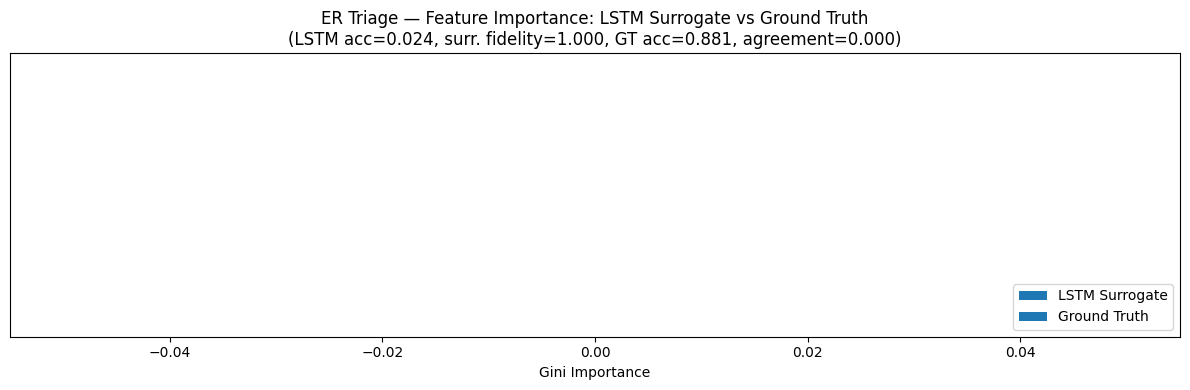

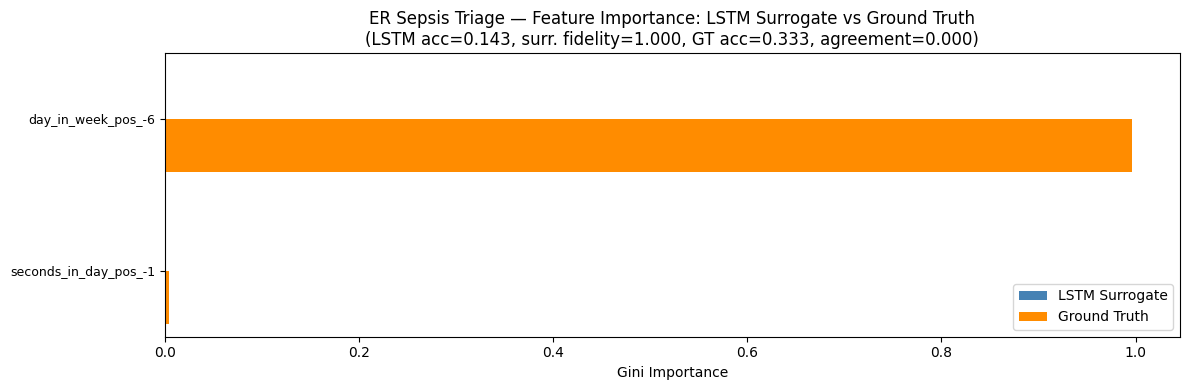

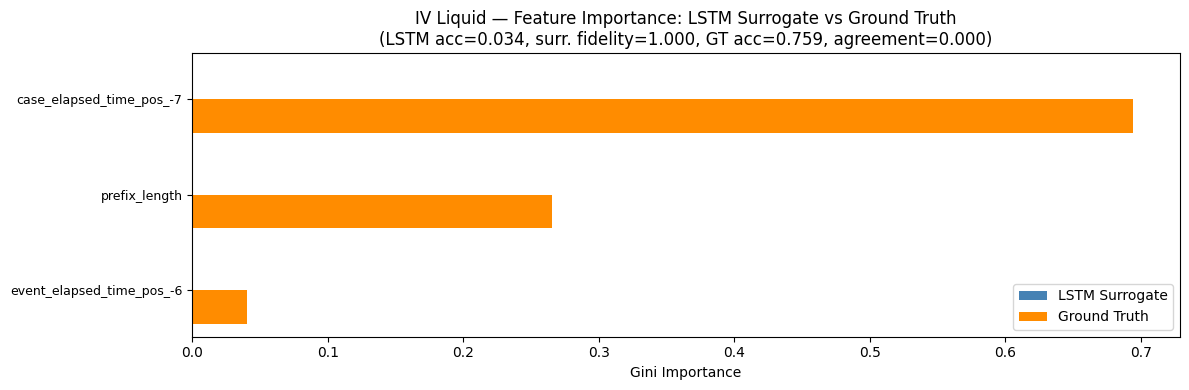

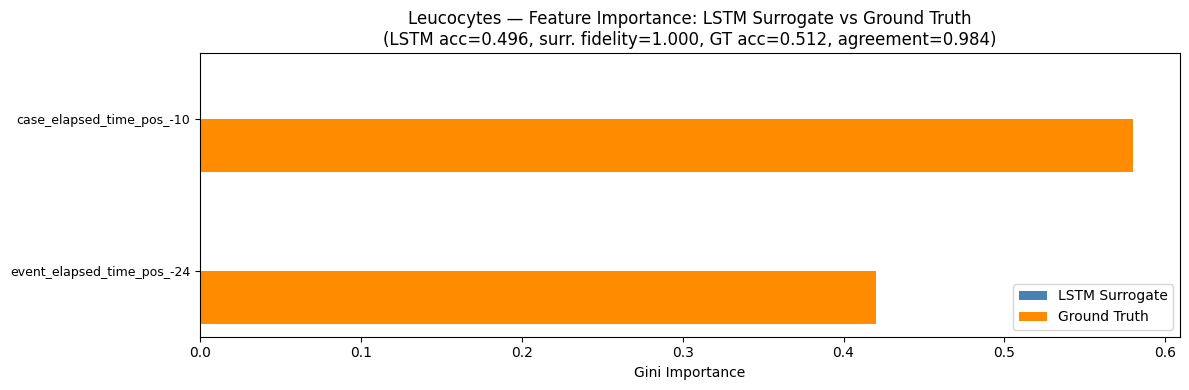

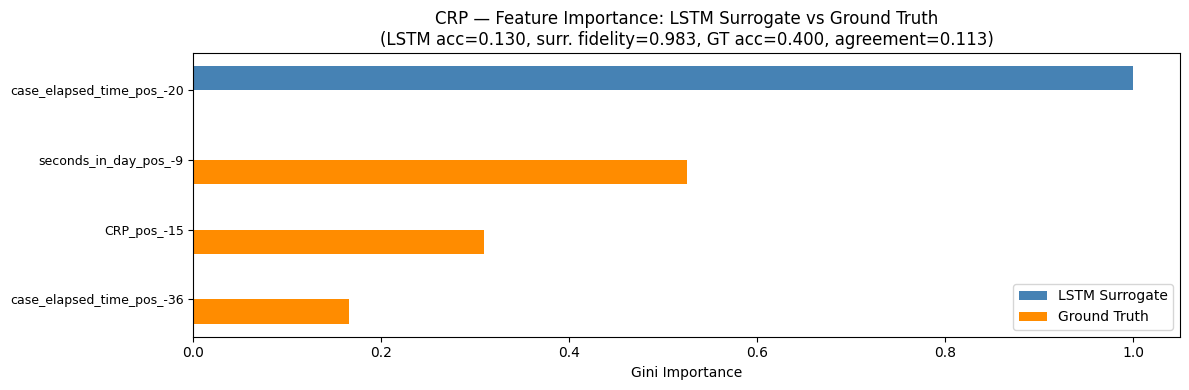

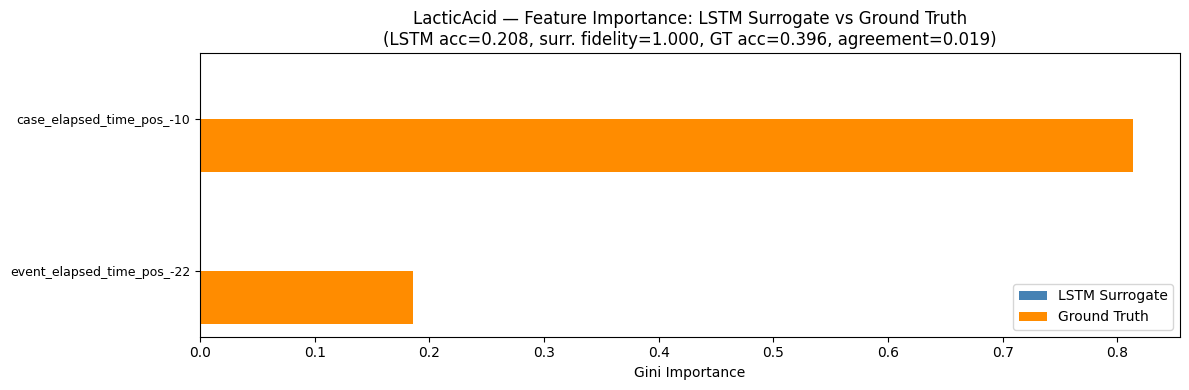

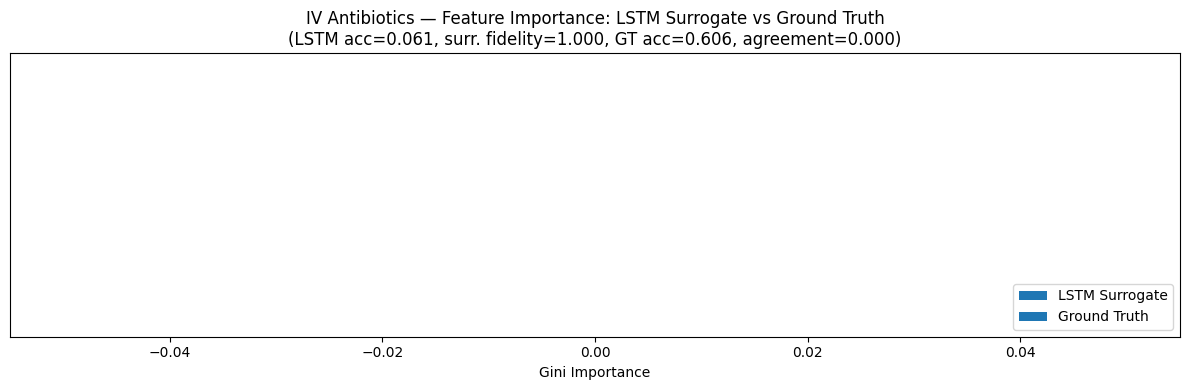

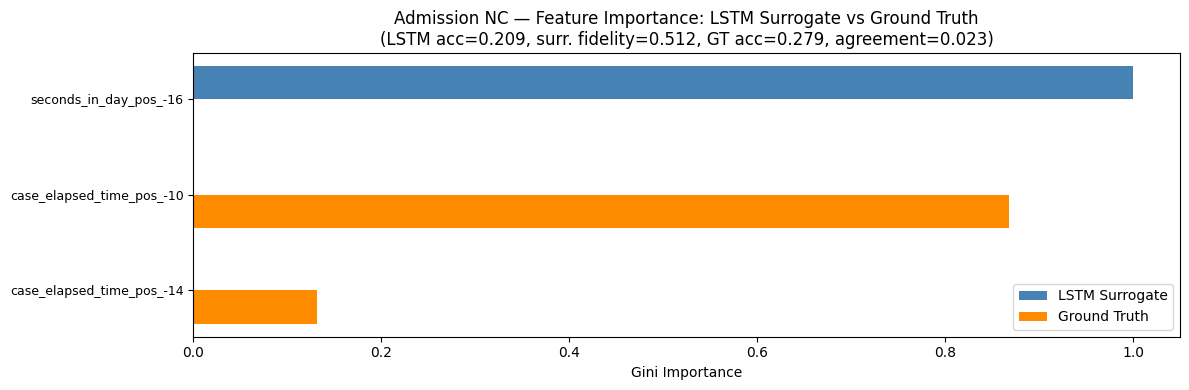

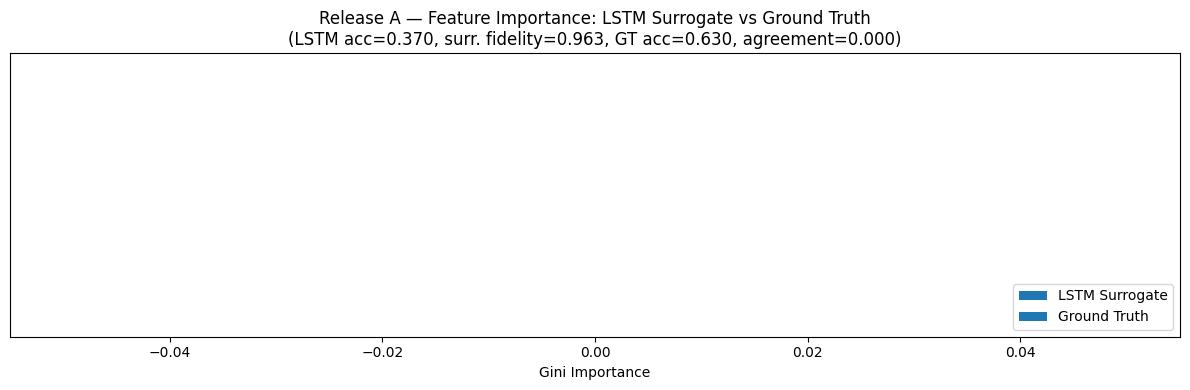

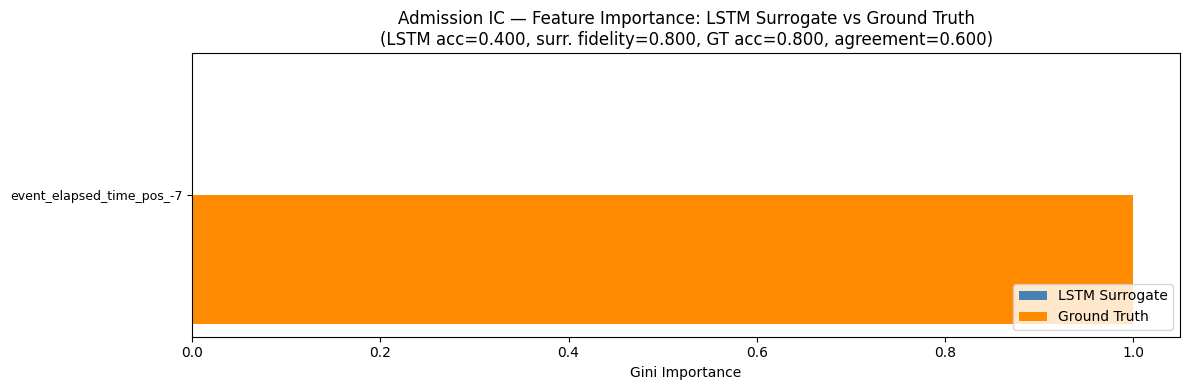

In [38]:
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_

    # Only show features with non-zero importance in either tree
    mask = (imp_lstm > 0) | (imp_gt > 0)
    fn_nz = [f for f, m in zip(fn, mask) if m]
    imp_lstm_nz = imp_lstm[mask]
    imp_gt_nz = imp_gt[mask]

    # Sort by max importance across both
    order = np.argsort(np.maximum(imp_lstm_nz, imp_gt_nz))[::-1]
    fn_nz = [fn_nz[i] for i in order]
    imp_lstm_nz = imp_lstm_nz[order]
    imp_gt_nz = imp_gt_nz[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(fn_nz) * 0.4)))
    y_pos = np.arange(len(fn_nz))
    bar_h = 0.35

    ax.barh(y_pos - bar_h / 2, imp_lstm_nz, bar_h, label='LSTM Surrogate', color='steelblue')
    ax.barh(y_pos + bar_h / 2, imp_gt_nz, bar_h, label='Ground Truth', color='darkorange')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_nz, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Gini Importance')
    ax.set_title(f'{gateway_act} — Feature Importance: LSTM Surrogate vs Ground Truth\n'
                 f'(LSTM acc={gr["lstm_accuracy"]:.3f}, '
                 f'surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
                 f'GT acc={gr["gt_accuracy"]:.3f}, '
                 f'agreement={gr["agreement"]:.3f})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Side-by-side tree visualizations

Trees are capped at **depth 4** for readability. Full decision logic is in the
if/then rules section below. Split conditions show decoded category names.

In [39]:
# C4.5 trees have multi-way splits and cannot use sklearn's plot_tree.
# Instead, print the tree as readable rules.

def print_tree_rules(clf, label, max_rules=15):
    rules = clf.extract_rules()
    print(f'\n  {label} ({len(rules)} rules, showing top {min(max_rules, len(rules))}):')
    print(f'  {"─" * 70}')
    for i, rule in enumerate(rules[:max_rules]):
        conds = '\n      AND '.join(rule['conditions'])
        print(f'  Rule {i+1} (n={rule["n_samples"]}, {rule["confidence"]:.0%} confidence):')
        print(f'    IF  {conds}')
        print(f'    THEN -> {rule["prediction"]}')
        print()


for gateway_act, gr in gateway_results.items():
    print(f'{"=" * 80}')
    print(f'GATEWAY: {gateway_act}')
    print_tree_rules(gr['clf_lstm'], 'LSTM Surrogate (C4.5)')
    print_tree_rules(gr['clf_gt'], 'Ground Truth (C4.5)')

GATEWAY: ER Registration

  LSTM Surrogate (C4.5) (1 rules, showing top 1):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=125, 100% confidence):
    IF  
    THEN -> CRP


  Ground Truth (C4.5) (1 rules, showing top 1):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=125, 92% confidence):
    IF  
    THEN -> ER Triage

GATEWAY: ER Triage

  LSTM Surrogate (C4.5) (1 rules, showing top 1):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=125, 100% confidence):
    IF  
    THEN -> CRP


  Ground Truth (C4.5) (1 rules, showing top 1):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=125, 86% confidence):
    IF  
    THEN -> ER Sepsis Triage

GATEWAY: ER Sepsis Triage

  LSTM Surrogate (C4.5) (1 rules, showing top 1):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=125, 100% confidence):
    IF  
    THEN 

## Decision rules as readable if/then statements

Each leaf becomes one rule. Conditions along the path from root to leaf are
combined with AND. Rules are sorted by sample count (most common decisions
first).

In [40]:
# Rule extraction is now built into C45Classifier.extract_rules()
# (printed in the cell above)

## Confusion: surrogate predictions vs ground truth predictions

Where do the two trees disagree? Each cell shows how many test samples the
LSTM surrogate assigned to one branch while the ground truth tree assigned
to another.

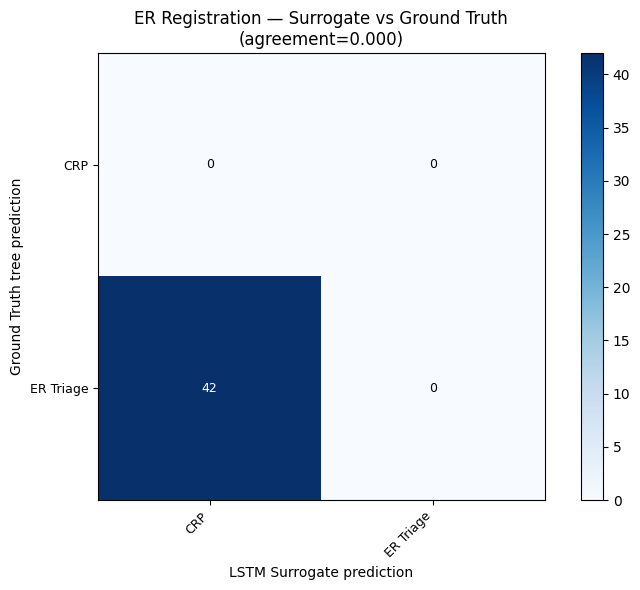

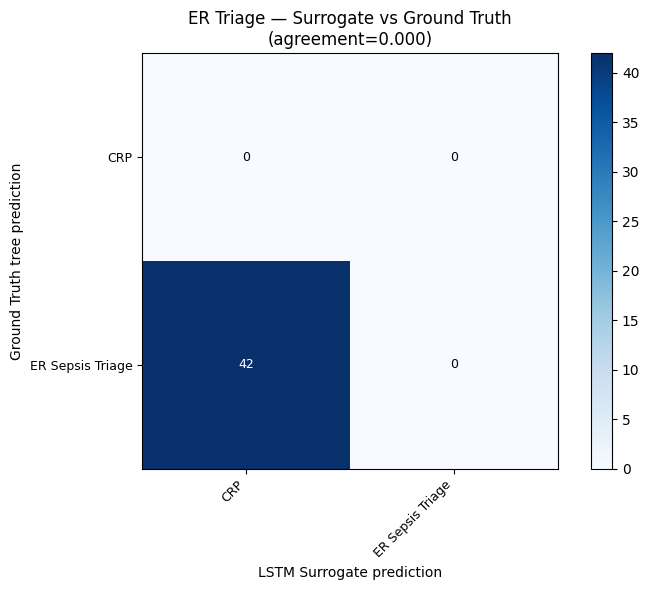

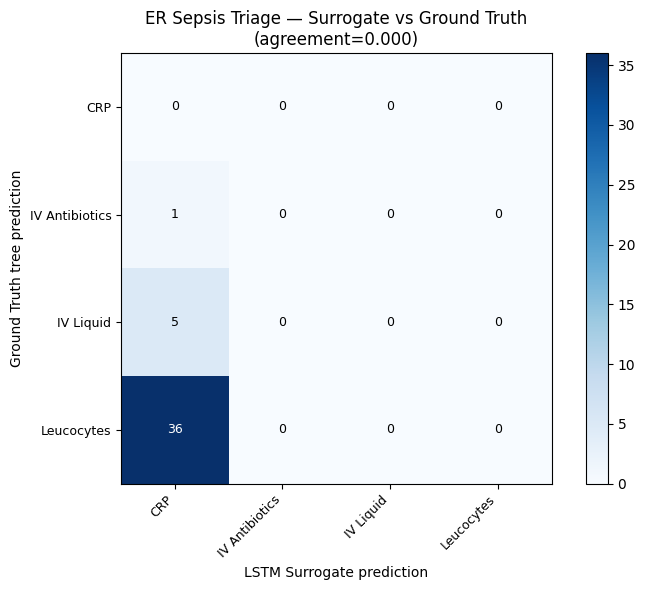

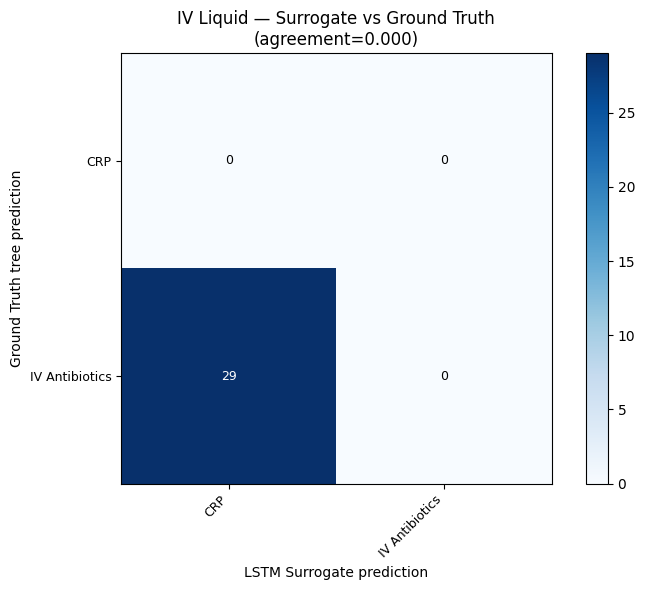

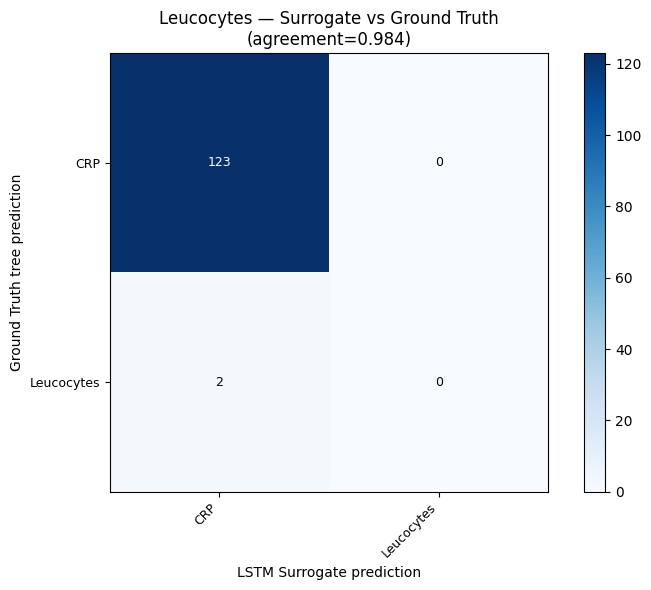

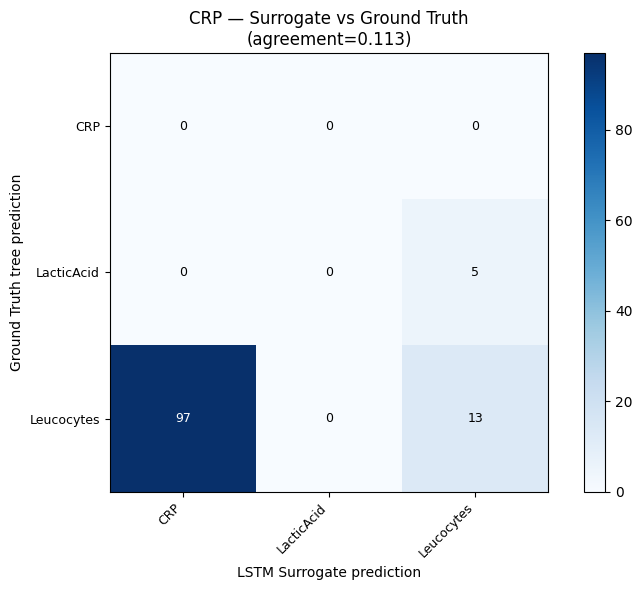

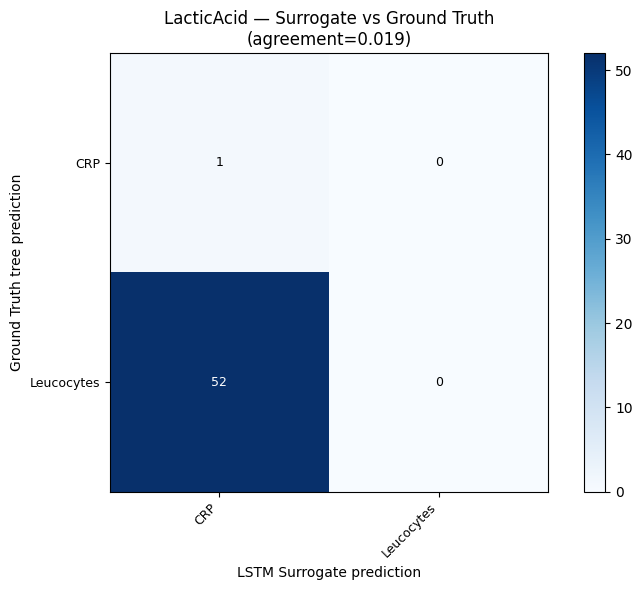

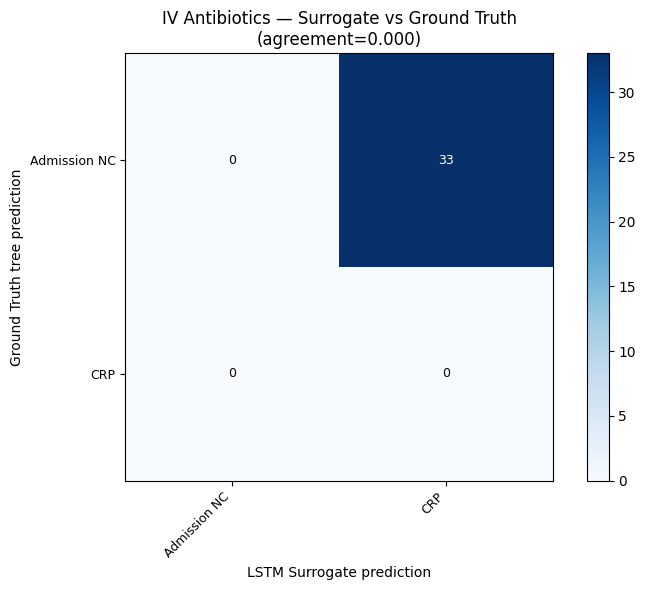

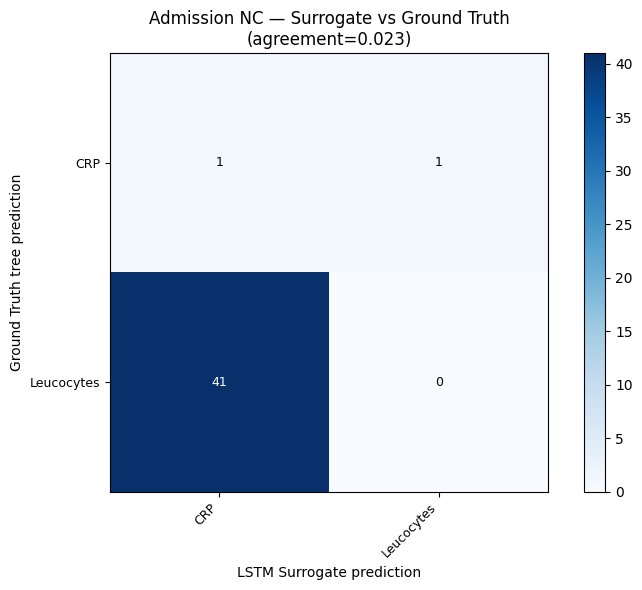

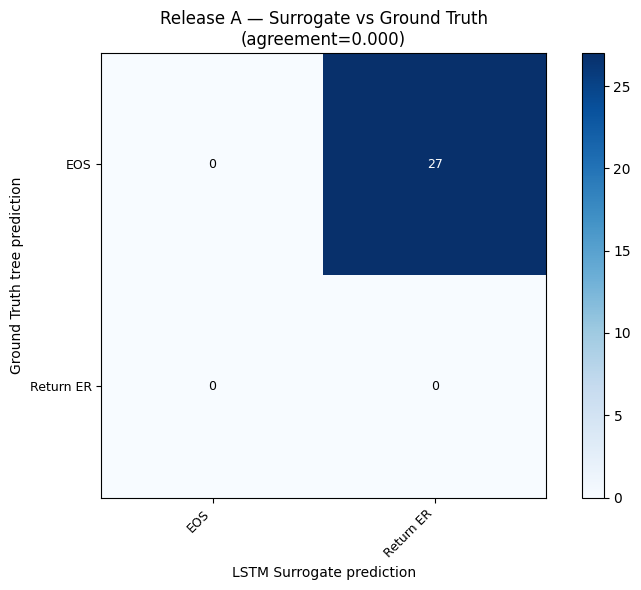

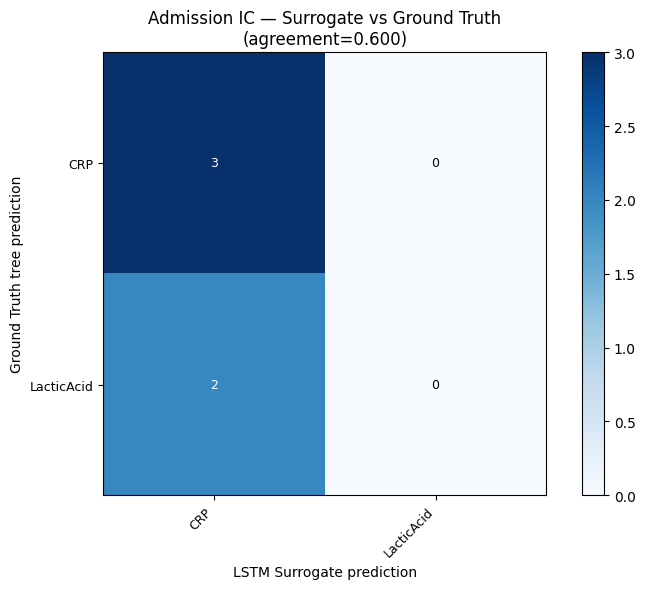

In [41]:
for gateway_act, gr in gateway_results.items():
    y_surr = gr['clf_lstm'].predict(gr['X_test'])
    y_gt = gr['clf_gt'].predict(gr['X_test'])

    labels = sorted(set(y_surr) | set(y_gt))
    cm = confusion_matrix(y_gt, y_surr, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('LSTM Surrogate prediction')
    ax.set_ylabel('Ground Truth tree prediction')
    ax.set_title(f'{gateway_act} — Surrogate vs Ground Truth\n(agreement={gr["agreement"]:.3f})')
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

## Deep dive: disagreement analysis

For the gateway with the lowest agreement rate, examine individual test cases
where the surrogate and ground truth trees predict different branches. Shows
what the LSTM actually predicted vs what happened, and which features are at
play.

In [42]:
# Find gateway with lowest agreement
worst_gateway = min(gateway_results, key=lambda g: gateway_results[g]['agreement'])
gr = gateway_results[worst_gateway]
print(f'Deepest disagreement: {worst_gateway} (agreement={gr["agreement"]:.3f})\n')

y_surr = gr['clf_lstm'].predict(gr['X_test'])
y_gt_pred = gr['clf_gt'].predict(gr['X_test'])
disagree_mask = y_surr != y_gt_pred
disagree_indices = np.where(disagree_mask)[0]

n_show = min(8, len(disagree_indices))
rng = np.random.RandomState(42)
show_indices = rng.choice(disagree_indices, size=n_show, replace=False) if len(disagree_indices) > 0 else []

for idx in show_indices:
    sample = gr['X_test'].iloc[idx]
    lstm_pred = gr['y_lstm_test'].iloc[idx] if hasattr(gr['y_lstm_test'], 'iloc') else gr['y_lstm_test'][idx]
    actual = gr['y_actual_test'].iloc[idx] if hasattr(gr['y_actual_test'], 'iloc') else gr['y_actual_test'][idx]
    surr_pred = y_surr[idx]
    gt_pred = y_gt_pred[idx]

    print(f'{"=" * 80}')
    print(f'Actual next: {actual} | LSTM predicted: {lstm_pred}')
    print(f'Surrogate tree: {surr_pred} | GT tree: {gt_pred}')

    print(f'\n  Surrogate path:')
    for i, step in enumerate(gr['clf_lstm'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {surr_pred}')

    print(f'\n  GT path:')
    for i, step in enumerate(gr['clf_gt'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {gt_pred}')
    print()

Deepest disagreement: ER Registration (agreement=0.000)

Actual next: Leucocytes | LSTM predicted: CRP
Surrogate tree: CRP | GT tree: ER Triage

  Surrogate path:
    -> CRP

  GT path:
    -> ER Triage

Actual next: ER Triage | LSTM predicted: CRP
Surrogate tree: CRP | GT tree: ER Triage

  Surrogate path:
    -> CRP

  GT path:
    -> ER Triage

Actual next: ER Triage | LSTM predicted: CRP
Surrogate tree: CRP | GT tree: ER Triage

  Surrogate path:
    -> CRP

  GT path:
    -> ER Triage

Actual next: ER Triage | LSTM predicted: CRP
Surrogate tree: CRP | GT tree: ER Triage

  Surrogate path:
    -> CRP

  GT path:
    -> ER Triage

Actual next: ER Sepsis Triage | LSTM predicted: CRP
Surrogate tree: CRP | GT tree: ER Triage

  Surrogate path:
    -> CRP

  GT path:
    -> ER Triage

Actual next: ER Triage | LSTM predicted: CRP
Surrogate tree: CRP | GT tree: ER Triage

  Surrogate path:
    -> CRP

  GT path:
    -> ER Triage

Actual next: ER Triage | LSTM predicted: CRP
Surrogate tree

## Side-by-side trees: Ground Truth vs LSTM Surrogate

For each gateway, the ground-truth decision tree (left) next to the LSTM
surrogate tree (right). Orange nodes are internal splits; blue nodes are leaves
showing the predicted class, sample count and confidence. Subtrees whose leaves
all predict the same class have been collapsed (same-prediction pruning).

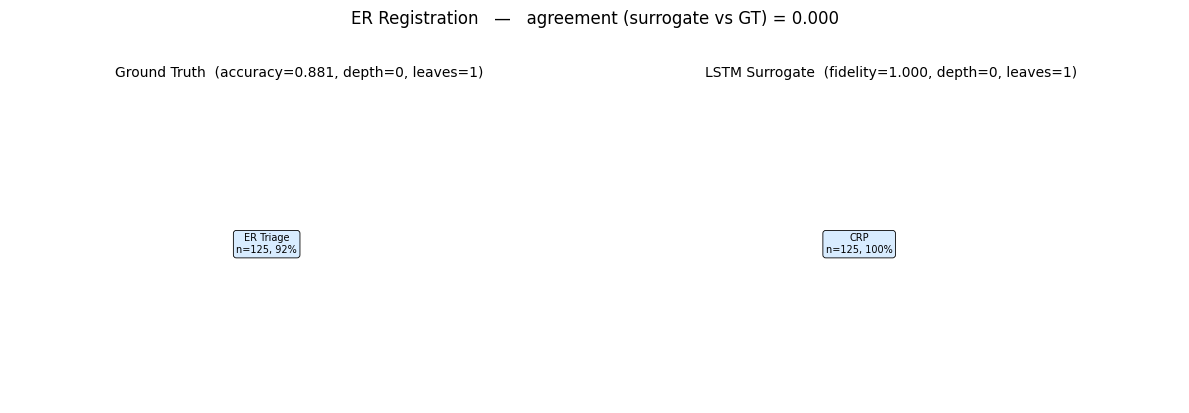

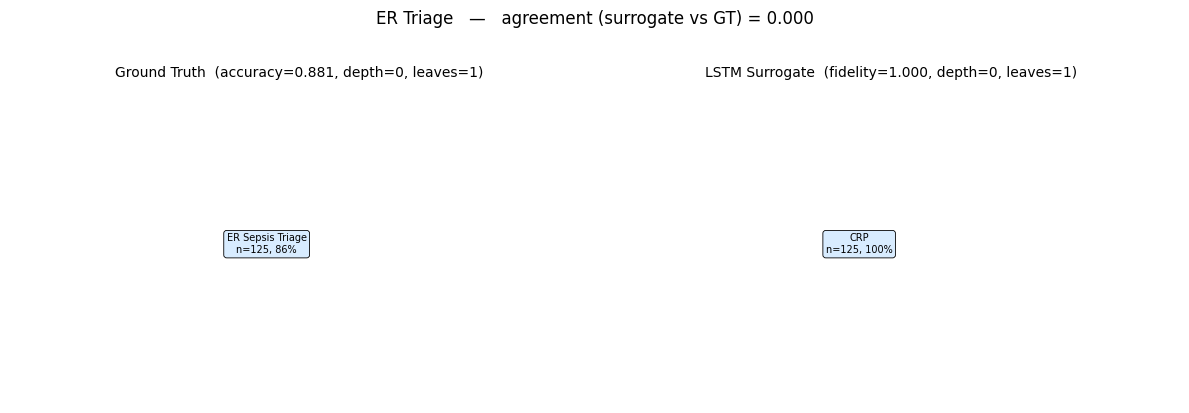

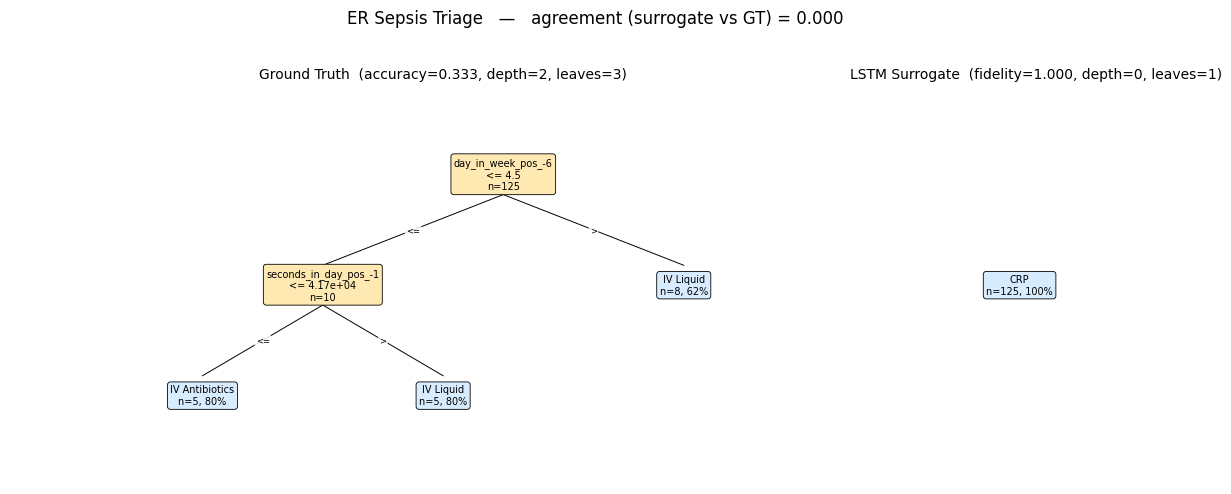

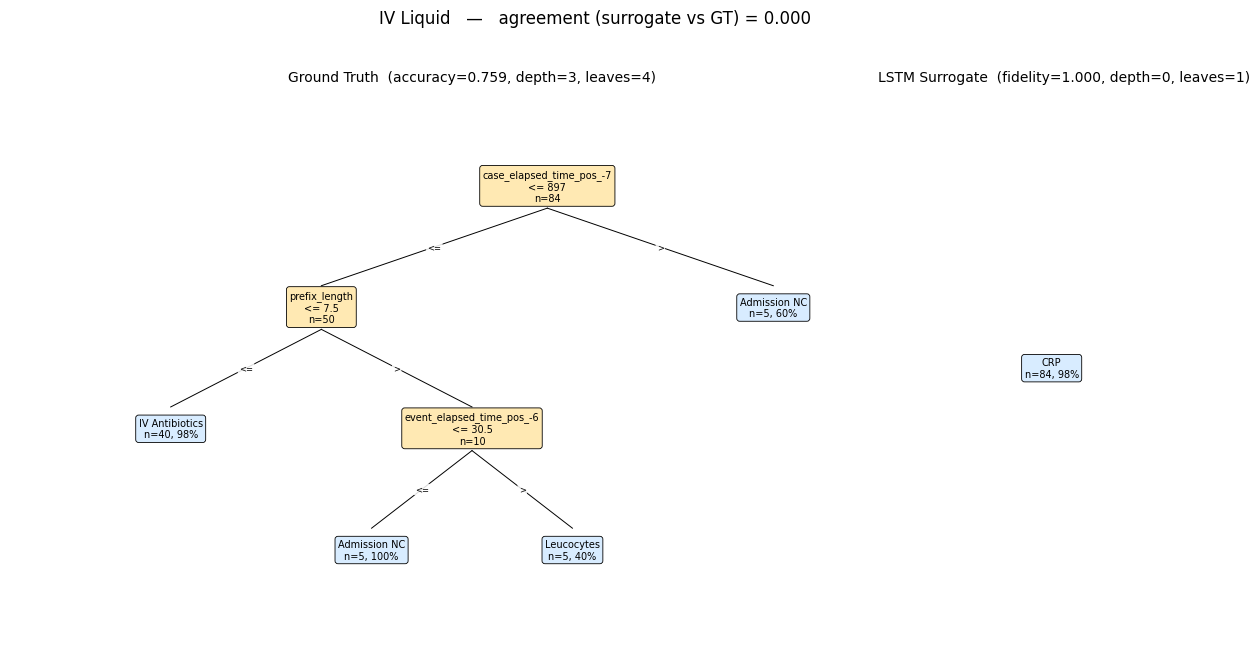

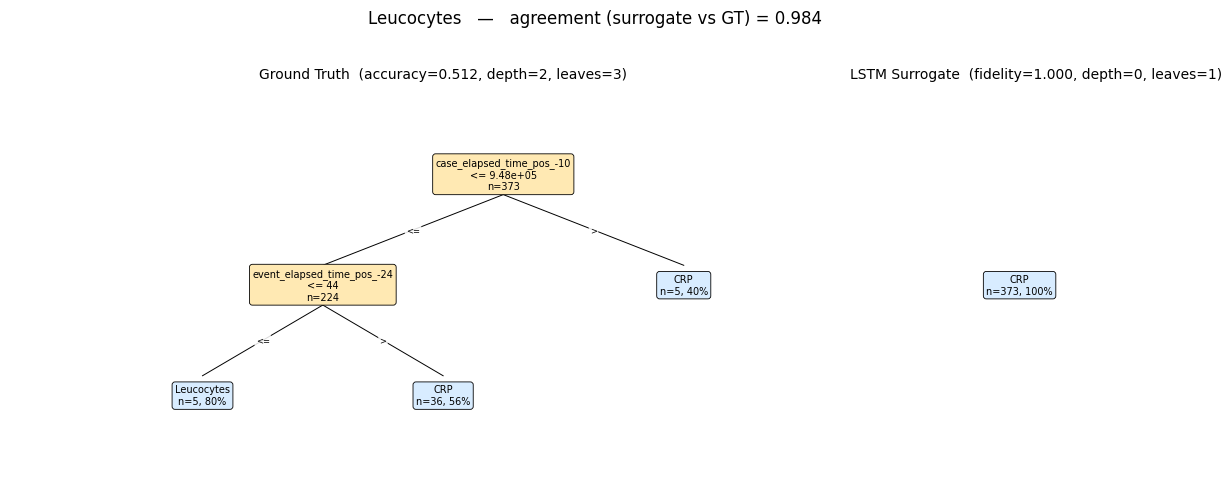

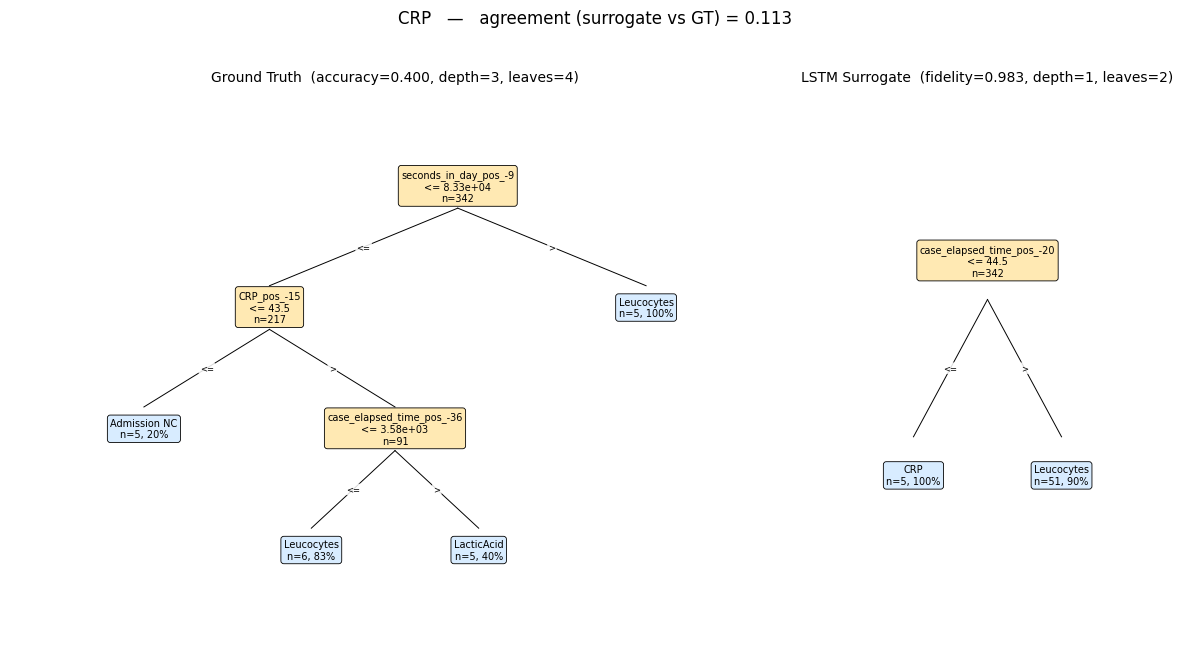

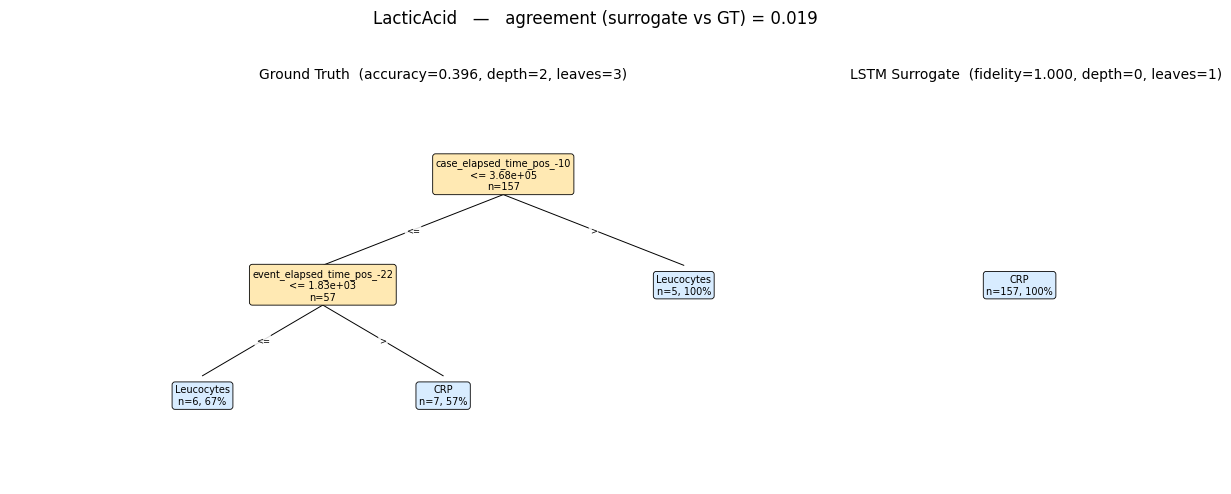

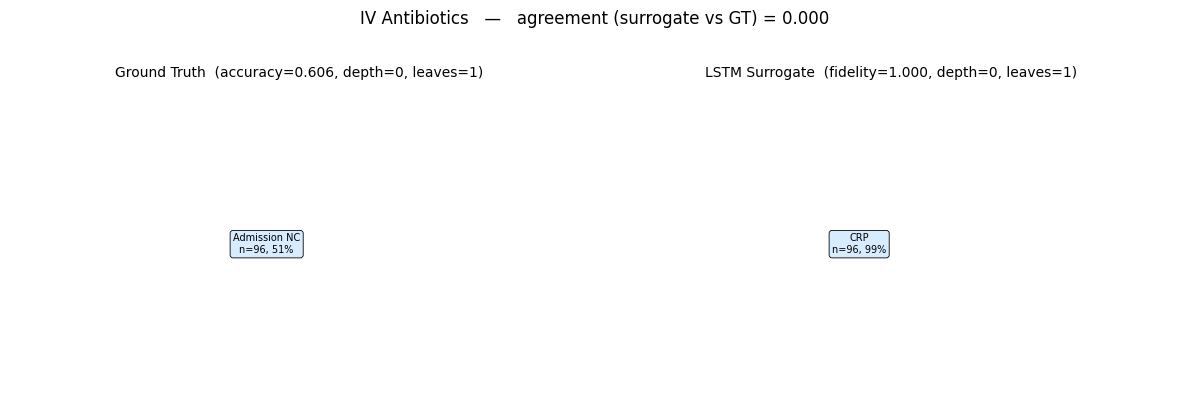

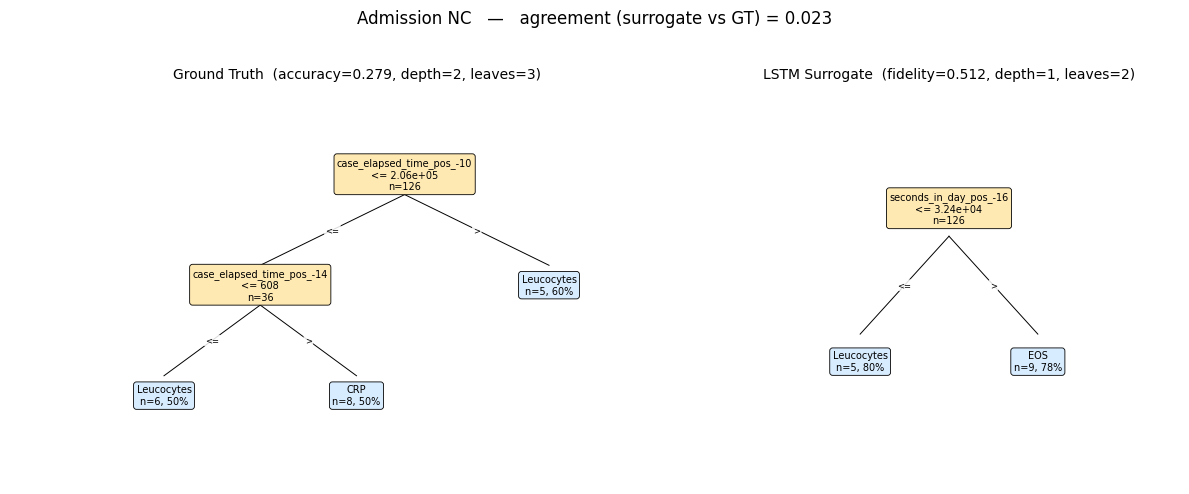

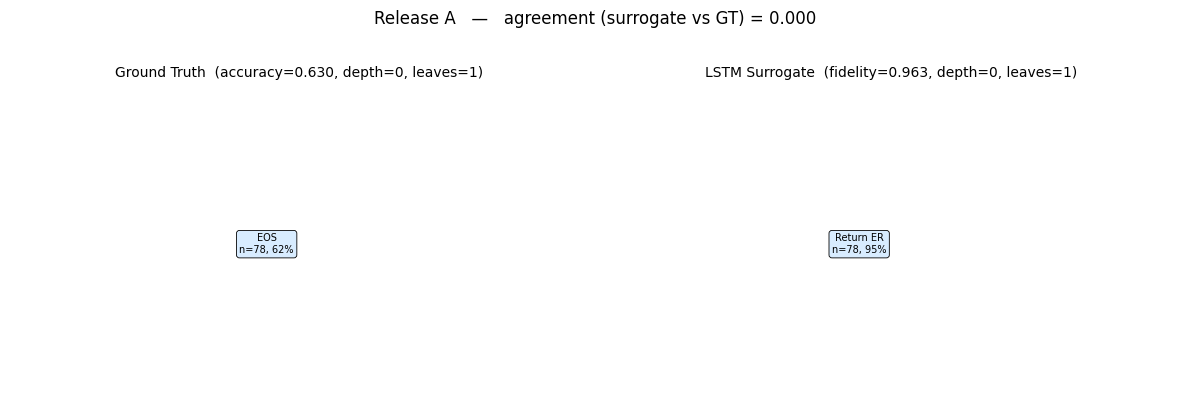

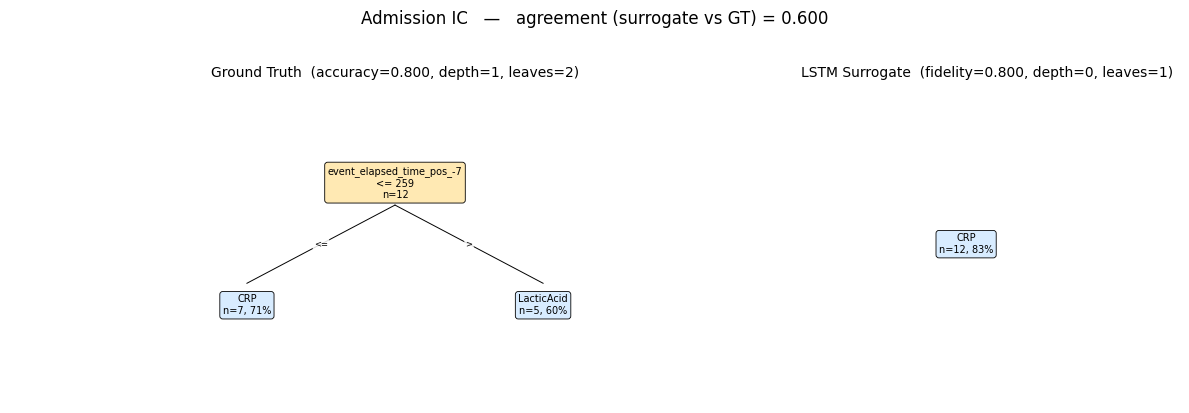

In [43]:
def plot_c45_tree_ax(clf, ax, title=''):
    """Render a C4.5 tree into a given matplotlib axis."""
    root = clf.root_
    if root is None:
        return

    positions = {}
    leaf_counter = [0]

    def assign_x(node, depth):
        if not node.children:
            positions[id(node)] = (leaf_counter[0], -depth)
            leaf_counter[0] += 1
            return positions[id(node)][0]
        child_xs = [assign_x(c, depth + 1) for c in node.children]
        x = (min(child_xs) + max(child_xs)) / 2.0
        positions[id(node)] = (x, -depth)
        return x

    assign_x(root, 0)
    max_depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()

    def fmt_cat_label(lbl):
        if isinstance(lbl, (list, tuple, set, frozenset)):
            vals = [str(v) for v in lbl]
            if len(vals) > 3:
                return '{' + ', '.join(vals[:3]) + f', +{len(vals) - 3}' + '}'
            return '{' + ', '.join(vals) + '}'
        return str(lbl)

    def draw(node):
        x, y = positions[id(node)]
        is_leaf = not node.children
        if is_leaf:
            total = sum(node.class_distribution.values())
            conf = (node.class_distribution.get(node.majority_class, 0) / total) if total else 0
            text = f'{node.majority_class}\nn={node.n_samples}, {conf:.0%}'
            color = '#d8ecff'
        else:
            if node.is_categorical:
                text = f'{node.feature}\nn={node.n_samples}'
            else:
                text = f'{node.feature}\n<= {node.threshold:.3g}\nn={node.n_samples}'
            color = '#ffe9b3'
        ax.text(x, y, text, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          edgecolor='black', linewidth=0.6))
        if is_leaf:
            return
        for i, child in enumerate(node.children):
            cx, cy = positions[id(child)]
            ax.plot([x, cx], [y - 0.18, cy + 0.18], 'k-', lw=0.7)
            if node.is_categorical:
                lbl = node.branch_labels[i] if i < len(node.branch_labels) else str(i)
                edge_text = fmt_cat_label(lbl)
            else:
                edge_text = '<=' if i == 0 else '>'
            mx, my = (x + cx) / 2, (y + cy) / 2
            ax.text(mx, my, edge_text, fontsize=6, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='none', alpha=0.85))
            draw(child)

    draw(root)
    ax.set_xlim(-0.8, max(n_leaves - 0.2, 1.0))
    ax.set_ylim(-max_depth - 0.8, 0.8)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)


# --- Side-by-side Ground Truth vs Surrogate per gateway ---
for gateway_act, gr in gateway_results.items():
    gt_clf = gr['clf_gt']
    surr_clf = gr['clf_lstm']

    gt_leaves = max(gt_clf.get_n_leaves(), 1)
    surr_leaves = max(surr_clf.get_n_leaves(), 1)
    gt_depth = gt_clf.get_depth()
    surr_depth = surr_clf.get_depth()

    max_depth = max(gt_depth, surr_depth)
    fig_w = min(32, max(12, (gt_leaves + surr_leaves) * 1.4))
    fig_h = min(18, max(4, (max_depth + 1) * 1.6))

    fig, axes = plt.subplots(
        1, 2, figsize=(fig_w, fig_h),
        gridspec_kw={'width_ratios': [gt_leaves, surr_leaves]},
    )

    plot_c45_tree_ax(
        gt_clf, axes[0],
        title=f'Ground Truth  (accuracy={gr["gt_accuracy"]:.3f}, '
              f'depth={gt_depth}, leaves={gt_clf.get_n_leaves()})'
    )
    plot_c45_tree_ax(
        surr_clf, axes[1],
        title=f'LSTM Surrogate  (fidelity={gr["surrogate_fidelity"]:.3f}, '
              f'depth={surr_depth}, leaves={surr_clf.get_n_leaves()})'
    )
    fig.suptitle(
        f'{gateway_act}   —   agreement (surrogate vs GT) = {gr["agreement"]:.3f}',
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## Cache trained trees

Training the GT and surrogate trees across all qualifying gateways can take a while.
The cells below let you persist the current `gateway_data` + `gateway_results`
to a pickle file and reload them in a later session, skipping cells 6 and 8.

In [44]:
import pickle

CACHE_PATH = _current / 'cache' / f'22_gateway_results_{CONFIG.dataset_name.lower()}.pkl'
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

_payload = {
    'gateway_data': gateway_data,
    'gateway_results': gateway_results,
    'feature_window': ACTIVITY_WINDOW,
    'event_cat_indices': EVENT_CAT_INDICES,
    'event_num_indices': EVENT_NUM_INDICES,
}
with open(CACHE_PATH, 'wb') as f:
    pickle.dump(_payload, f, protocol=pickle.HIGHEST_PROTOCOL)

_size_mb = CACHE_PATH.stat().st_size / 1024 / 1024
print(f'Saved {len(gateway_results)} gateways ({_size_mb:.1f} MB) -> {CACHE_PATH}')

Saved 11 gateways (81.2 MB) -> /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/cache/22_gateway_results_sepsis.pkl


In [45]:
# Load cached trees — run this INSTEAD of cells 6 and 8 to skip re-training.
# Requires the earlier setup cells (model, decoder, predictor, decision_points)
# to have been run.
import pickle

CACHE_PATH = _current / 'cache' / f'22_gateway_results_{CONFIG.dataset_name.lower()}.pkl'

with open(CACHE_PATH, 'rb') as f:
    _payload = pickle.load(f)

gateway_data = _payload['gateway_data']
gateway_results = _payload['gateway_results']

print(f'Loaded {len(gateway_results)} gateways from {CACHE_PATH}')
for _g, _r in gateway_results.items():
    print(f'  {_g:40s} fidelity={_r["surrogate_fidelity"]:.3f}, '
          f'gt_acc={_r["gt_accuracy"]:.3f}, agreement={_r["agreement"]:.3f}')

Loaded 11 gateways from /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/cache/22_gateway_results_sepsis.pkl
  ER Registration                          fidelity=1.000, gt_acc=0.881, agreement=0.000
  ER Triage                                fidelity=1.000, gt_acc=0.881, agreement=0.000
  ER Sepsis Triage                         fidelity=1.000, gt_acc=0.333, agreement=0.000
  IV Liquid                                fidelity=1.000, gt_acc=0.759, agreement=0.000
  Leucocytes                               fidelity=1.000, gt_acc=0.512, agreement=0.984
  CRP                                      fidelity=0.983, gt_acc=0.400, agreement=0.113
  LacticAcid                               fidelity=1.000, gt_acc=0.396, agreement=0.019
  IV Antibiotics                           fidelity=1.000, gt_acc=0.606, agreement=0.000
  Admission NC                             fidelity=0.512, gt_acc=0.279, agreement=0.023
  Release A                                fidelity=0